# Geometry and Mesh
## Parametric 2D airfoil stack in ANSYS DesignModeller and CFD enclosure
![Parametric Model](CFDEnclosure.png)
![Parametric Model](ParameterisedModel.png)

## Mesh
![Global Mesh](MeshGlobal.png)
![Refined Mesh](MeshFine.png)

In [ ]:
from distutils.command.clean import clean
from venv import create
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from colorama import init, Fore, Style
init(autoreset=True)

SCATTER_SIZE = 5

from scipy.optimize import curve_fit

def quadratic(xData, x0, x1):
    return (xData - x1)**2 + x0

SIZE_COLOR = Fore.YELLOW
scatterSize = 5

df = pd.read_csv("3rdRun/AMOPSensStudy.csv", delimiter='\t')
print(Fore.GREEN+df.columns)

print(f"{SIZE_COLOR}Unfiltered DF Size: {df.shape}")

cleanedDf = df.dropna()
print(f"{SIZE_COLOR}NaN Columns: {df.shape[0] - cleanedDf.shape[0]}")

filterConditions = {
    "Filter lift": np.abs(df["lift_op"]) <= 10e2,
    "Filter turb": df["turb_outlet_intensity_op"] <= 0.6,
    # "Filter xdim": df["XDim"] < 1,
}
for filter in filterConditions:
    originalSize = cleanedDf.shape[0]
    cleanedDf = cleanedDf[filterConditions[filter]] 
    print(f"{SIZE_COLOR}{filter}: {originalSize - cleanedDf.shape[0]}")

print(f"{SIZE_COLOR}Filtered DF Size: {cleanedDf.shape}")

Index(['#', 'E2Slot', 'E1Chord', 'E2AOA',
       'E2Overhang', 'E2Chord', 'E1AOA', 'E3AOA',
       'E3Chord', 'E3Overhang', 'E3Slot', 'drag_op',
       'lift_op', 'turb_outlet_intensity_op', 'E1TrailingX',
       'E2TrailingX', 'E3TrailingX', 'XDim', 'E1TrailingY',
       'E2TrailingY', 'E3TrailingY', 'YDim', 'LoD',
       'XBoundary', 'YBoundary', 'effOpt', 'liftBoundary',
       'flowSeparation'],
      dtype='object')
Unfiltered DF Size: (500, 28)
NaN Columns: 36


/var/folders/3t/6ptqm7j92svg0_9bf_q8fz900000gn/T/ipykernel_3456/2809554684.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cleanedDf = cleanedDf[filterConditions[filter]]


Filter lift: 25


/var/folders/3t/6ptqm7j92svg0_9bf_q8fz900000gn/T/ipykernel_3456/2809554684.py:35: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cleanedDf = cleanedDf[filterConditions[filter]]


Filter turb: 4
Filtered DF Size: (435, 28)


In [ ]:
cleanedDf["E2Slot_Norm"] = cleanedDf["E2Slot"] / cleanedDf["E2Chord"]
cleanedDf["E2Overhang_Norm"] = cleanedDf["E2Overhang"] / cleanedDf["E2Chord"]

cleanedDf["E3Slot_Norm"] = cleanedDf["E3Slot"] / cleanedDf["E3Chord"]
cleanedDf["E3Overhang_Norm"] = cleanedDf["E3Overhang"] / cleanedDf["E3Chord"]

cleanedDf["E2Chord_Norm"] = cleanedDf["E2Chord"] / cleanedDf["E1Chord"]
cleanedDf["E3Chord_Norm"] = cleanedDf["E3Chord"] / cleanedDf["E2Chord"]

In [ ]:
print(cleanedDf.columns)

Index(['#', 'E2Slot', 'E1Chord', 'E2AOA', 'E2Overhang', 'E2Chord', 'E1AOA',
       'E3AOA', 'E3Chord', 'E3Overhang', 'E3Slot', 'drag_op', 'lift_op',
       'turb_outlet_intensity_op', 'E1TrailingX', 'E2TrailingX', 'E3TrailingX',
       'XDim', 'E1TrailingY', 'E2TrailingY', 'E3TrailingY', 'YDim', 'LoD',
       'XBoundary', 'YBoundary', 'effOpt', 'liftBoundary', 'flowSeparation',
       'E2Slot_Norm', 'E2Overhang_Norm', 'E3Slot_Norm', 'E3Overhang_Norm',
       'E2Chord_Norm', 'E3Chord_Norm'],
      dtype='object')


In [ ]:
def createGraph(xData, yData, xParam, yParam, ax, deg = 2):
    N = len(xData)

    popt, pcov = np.polyfit(xData, yData, deg = deg, cov = True)

    ax.scatter(xData, yData, s = SCATTER_SIZE, c = 'tab:blue', label="Data")
    xFit = np.linspace(xData.min(), xData.max(), 1000)
    n = deg

    # print(popt)

    yFit = popt[0]*xFit**2 + popt[1]*xFit + popt[2]
    a = popt[0]
    b = popt[1]
    grad = np.array([
        b/(2*a**2), -1/(2*a)
    ])
    h = -b/(2*a)

    sigma_H = np.sqrt(grad @ pcov[:2, :2] @ grad)
    CI = 1.96*sigma_H

    ax.plot(xFit, yFit, c = 'tab:red', label=f"Fit. Peak @ {h:.2e} +/- {CI:.2e}")
    
    if (CI < (xData.max() - xData.min())):
        ax.axvline(h + CI, label = "95% CI", c = 'tab:orange', ls = '--')
        ax.axvline(h - CI, c = 'tab:orange', ls = '--')

    ax.set_ylabel(f"{yParam}")
    ax.set_title(f"{yParam} vs {xParam}")
    ax.legend()

FileNotFoundError: [Errno 2] No such file or directory: 'figures/E1AOA.png'

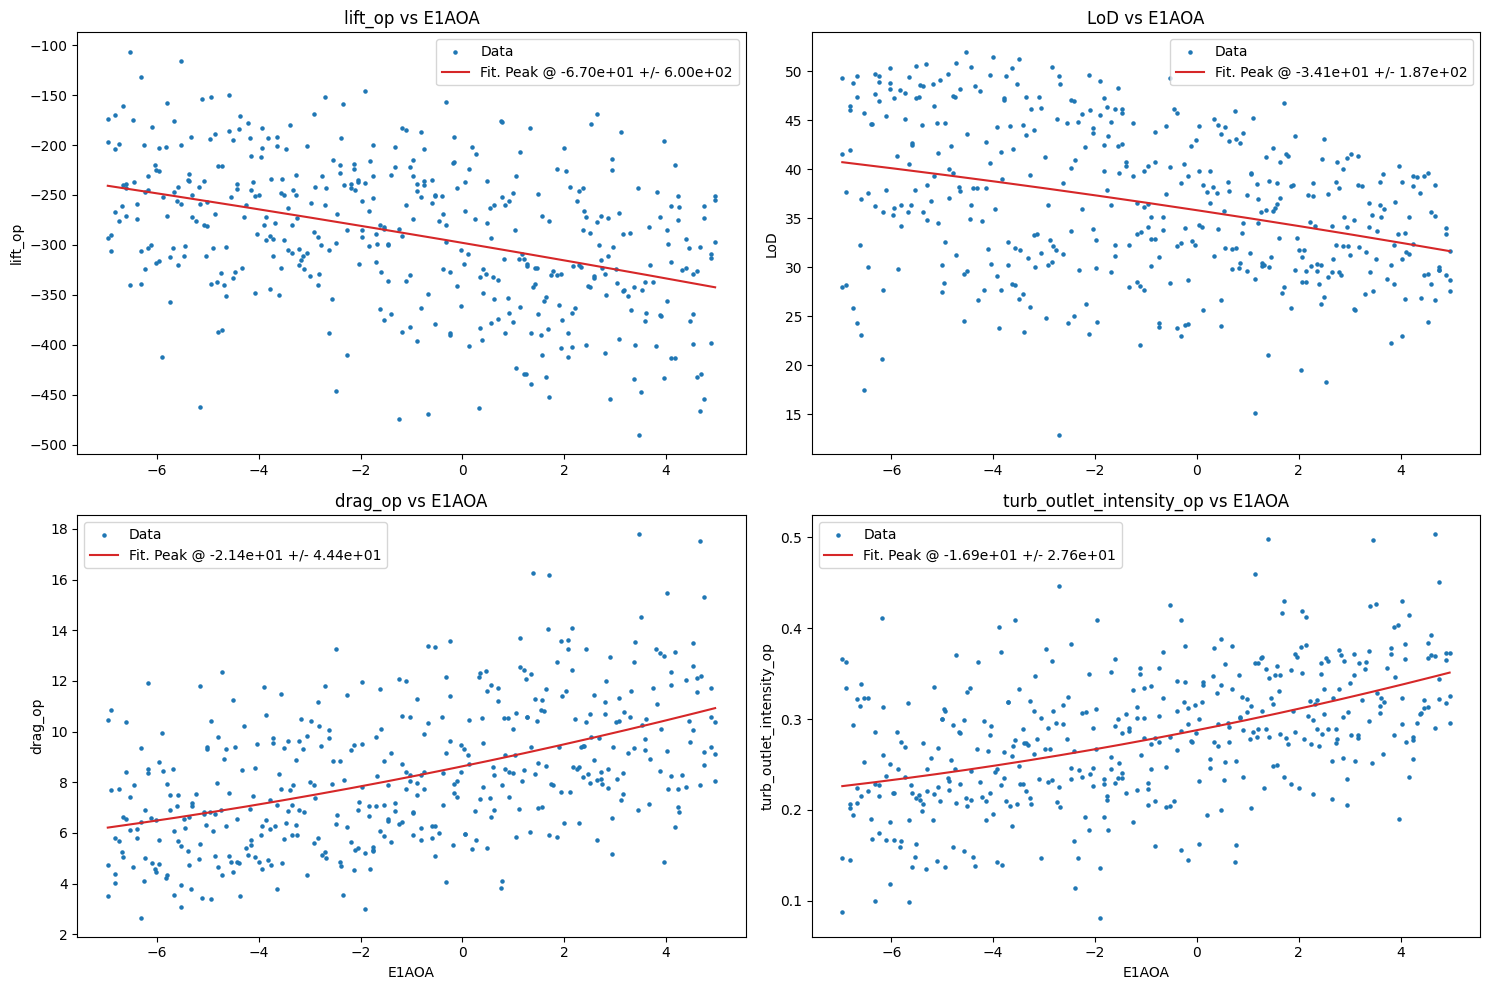

In [ ]:
XgraphParams = {
    "E1AOA": None,
    "E2AOA": None,
    "E3AOA": None,
    "E1Chord": None,
    "E2Chord_Norm": None, 
    "E3Chord_Norm": None,
    "E2Slot_Norm": None,
    "E2Overhang_Norm": None,
    "E3Slot_Norm": None,
    "E3Overhang_Norm": None,
}

YgraphParams = {
    "lift_op": None,
    "drag_op": None,
    "LoD": None,
    "turb_outlet_intensity_op": None
}

for xParam in XgraphParams:
    xData = cleanedDf[xParam]

    fig, axs = plt.subplots(2, 2, figsize = [15, 10])


    # popt, pcov = curve_fit(quadratic, xData, yData)
    deg = 2

    i_ax = 0
    j_ax = 0
    for yParam in YgraphParams:
        yData = cleanedDf[yParam]
        ax = axs[i_ax, j_ax]
        createGraph(xData, yData, xParam, yParam, ax = ax, deg = 2)
        i_ax = (i_ax+1)
        if (i_ax == 2):
            i_ax = 0
            j_ax += 1
        

    axs[1, 0].set_xlabel(f"{xParam}")
    axs[1, 1].set_xlabel(f"{xParam}")
    plt.tight_layout()
    plt.savefig(f"figures/{xParam}.png")
    plt.clf()